In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/Data/AAPL.csv")

In [4]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df = df.sort_values("Date")

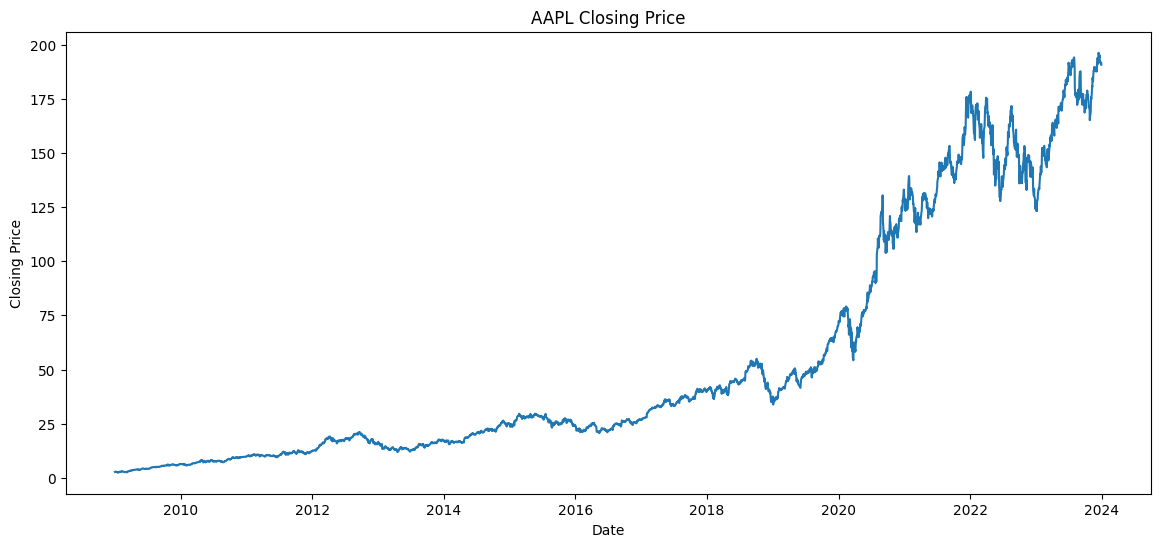

In [8]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"])

plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

In [9]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()

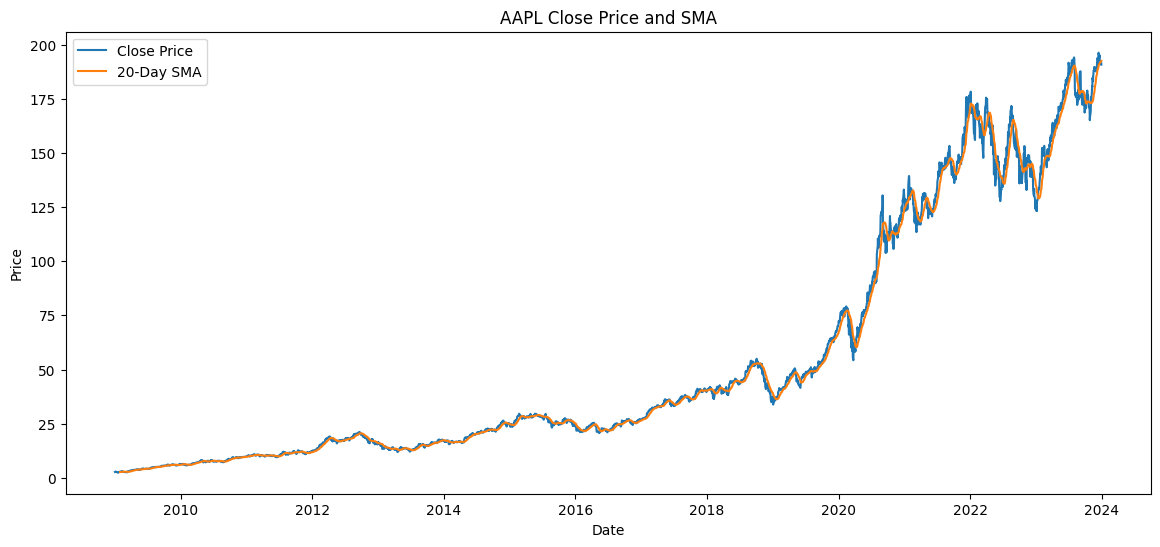

In [10]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["SMA_20"], label="20-Day SMA")

plt.title("AAPL Close Price and SMA")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [11]:
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

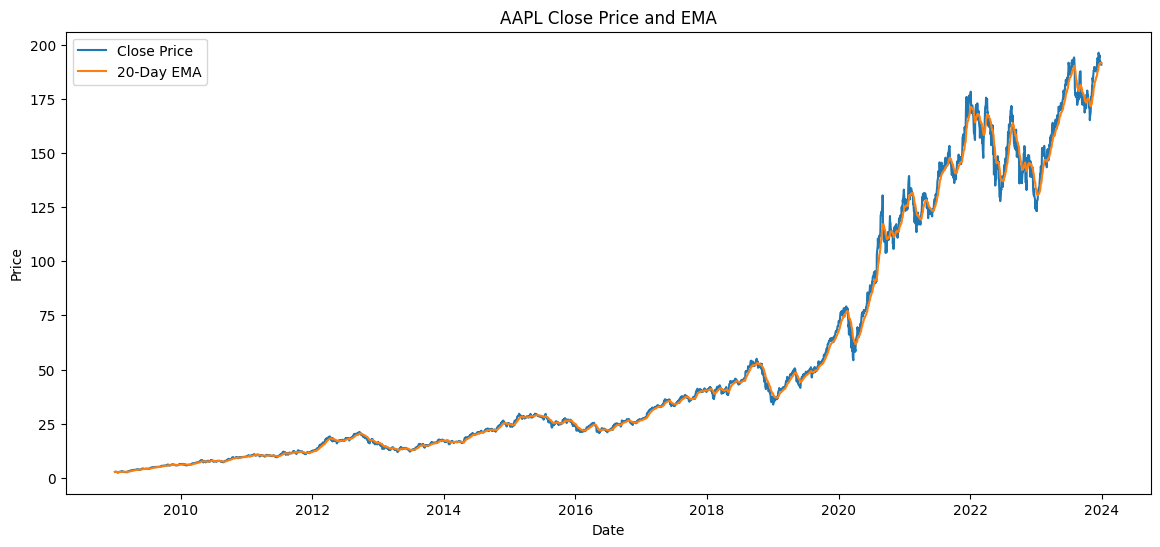

In [12]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["EMA_20"], label="20-Day EMA")

plt.title("AAPL Close Price and EMA")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [13]:
df["Daily_Return"] = df["Close"].pct_change()

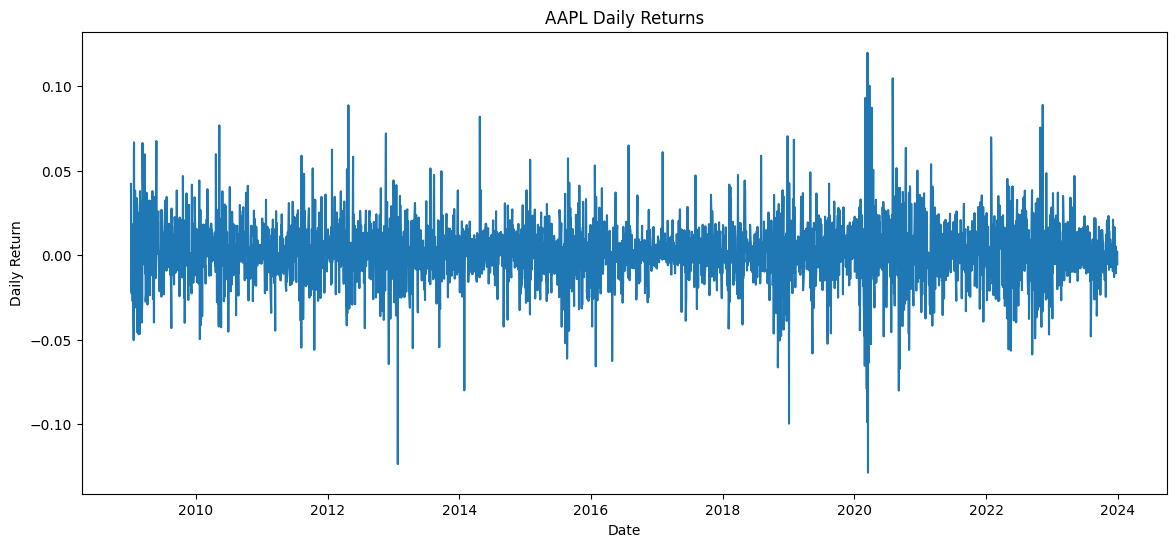

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Daily_Return"])

plt.title("AAPL Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

In [15]:
volatility = df["Daily_Return"].std()

volatility

np.float64(0.018010113628161184)

In [26]:
delta = df["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI"] = 100 - (100 / (1 + rs))

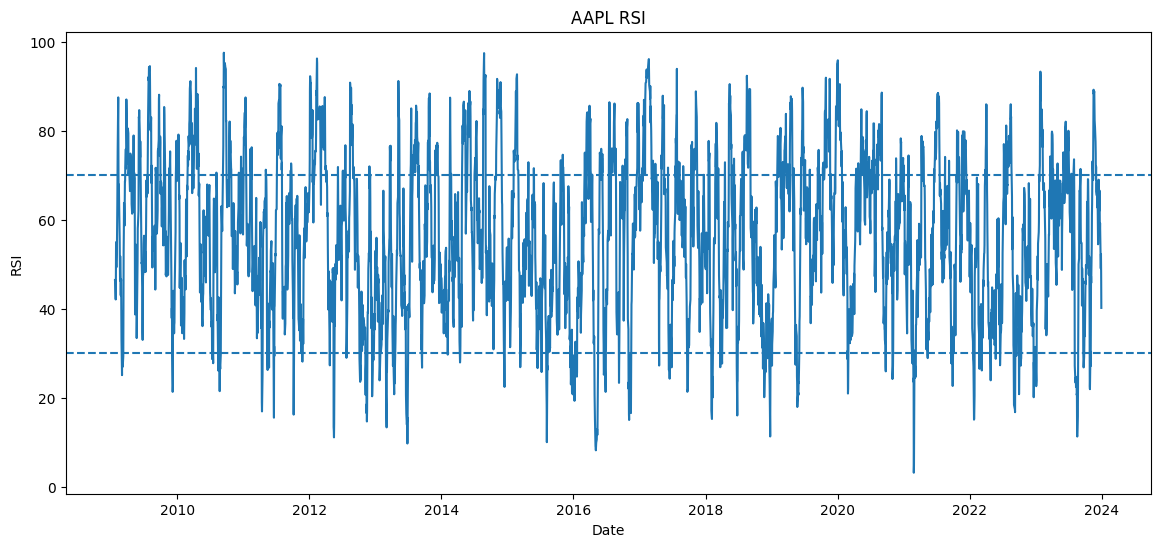

In [17]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["RSI"])

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("AAPL RSI")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.show()

In [23]:
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema_12 - ema_26

In [24]:
df["Signal_Line"] = df["MACD"].ewm(span=9, adjust=False).mean()

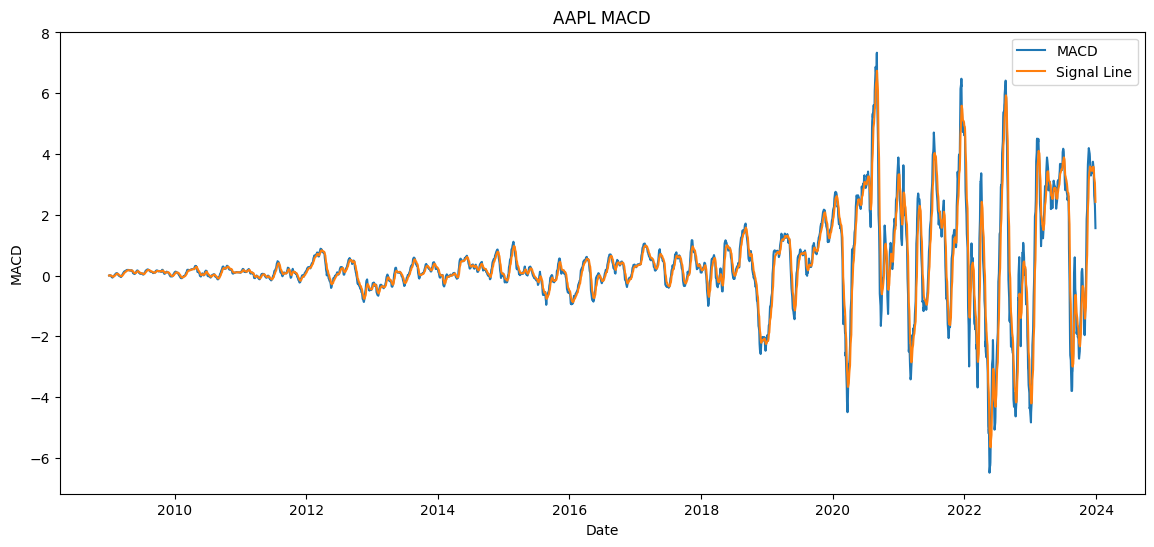

In [25]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["MACD"], label="MACD")
plt.plot(df["Date"], df["Signal_Line"], label="Signal Line")

plt.title("AAPL MACD")
plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()

plt.show()

In [22]:
df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,Daily_Return,RSI,MACD,Signal_Line
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,2.721686,NaN,NaN,0.000000,0.000000
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,2.732626,0.042204,NaN,0.009163,0.001833
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,2.738068,-0.016494,NaN,0.012506,0.003967
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,2.737250,-0.021609,NaN,0.010173,0.005208
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,2.741338,0.018570,NaN,0.012273,0.006621


In [34]:
stocks = ["AAPL", "AMZN", "GOOG", "META", "NVDA"]

stock_data = {}

In [37]:
for stock in stocks:
    path = f"../data/raw/data/{stock}.csv"

    temp_df = pd.read_csv(path)

    temp_df["Date"] = pd.to_datetime(temp_df["Date"])

    temp_df = temp_df.sort_values("Date")

    stock_data[stock] = temp_df

In [38]:
stock_data.keys()

dict_keys(['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA'])

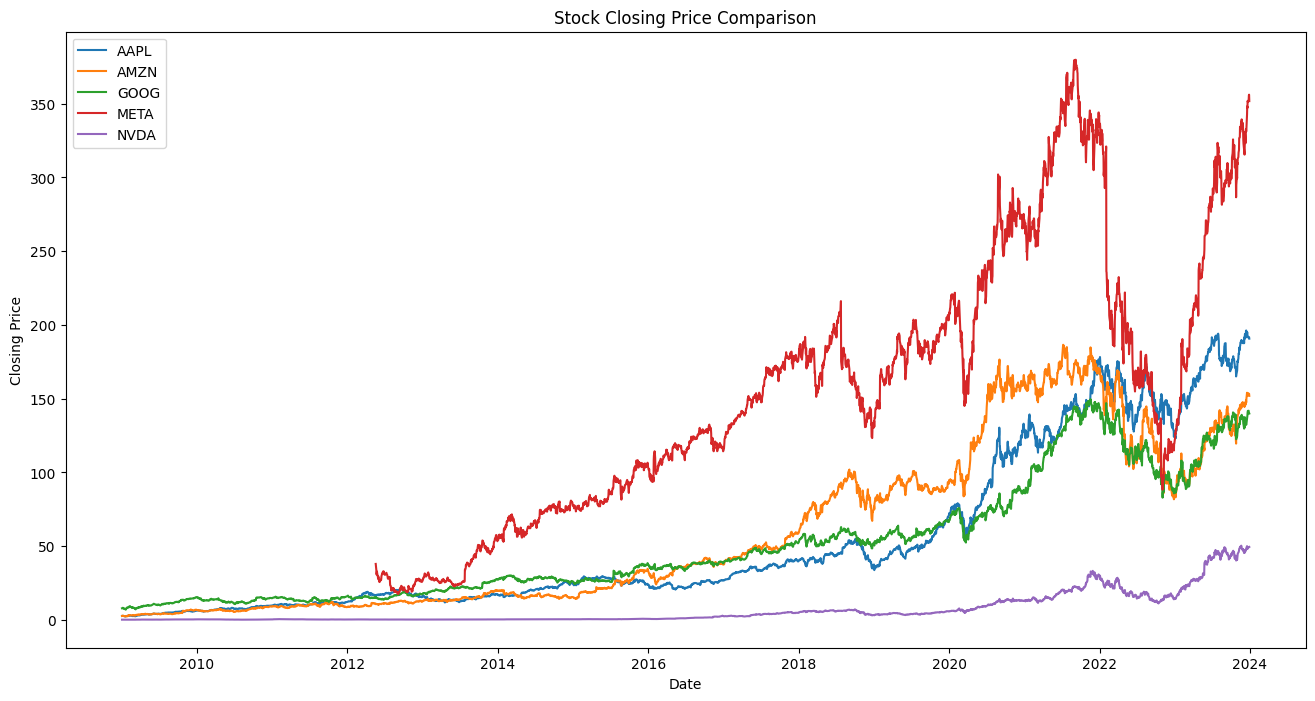

In [39]:
plt.figure(figsize=(16,8))

for stock in stocks:
    plt.plot(
        stock_data[stock]["Date"],
        stock_data[stock]["Close"],
        label=stock
    )

plt.title("Stock Closing Price Comparison")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

In [40]:
normalized_prices = pd.DataFrame()

In [41]:
for stock in stocks:
    temp_df = stock_data[stock]

    normalized_prices[stock] = (
        temp_df["Close"] / temp_df["Close"].iloc[0]
    )

In [42]:
normalized_prices["Date"] = stock_data["AAPL"]["Date"].values

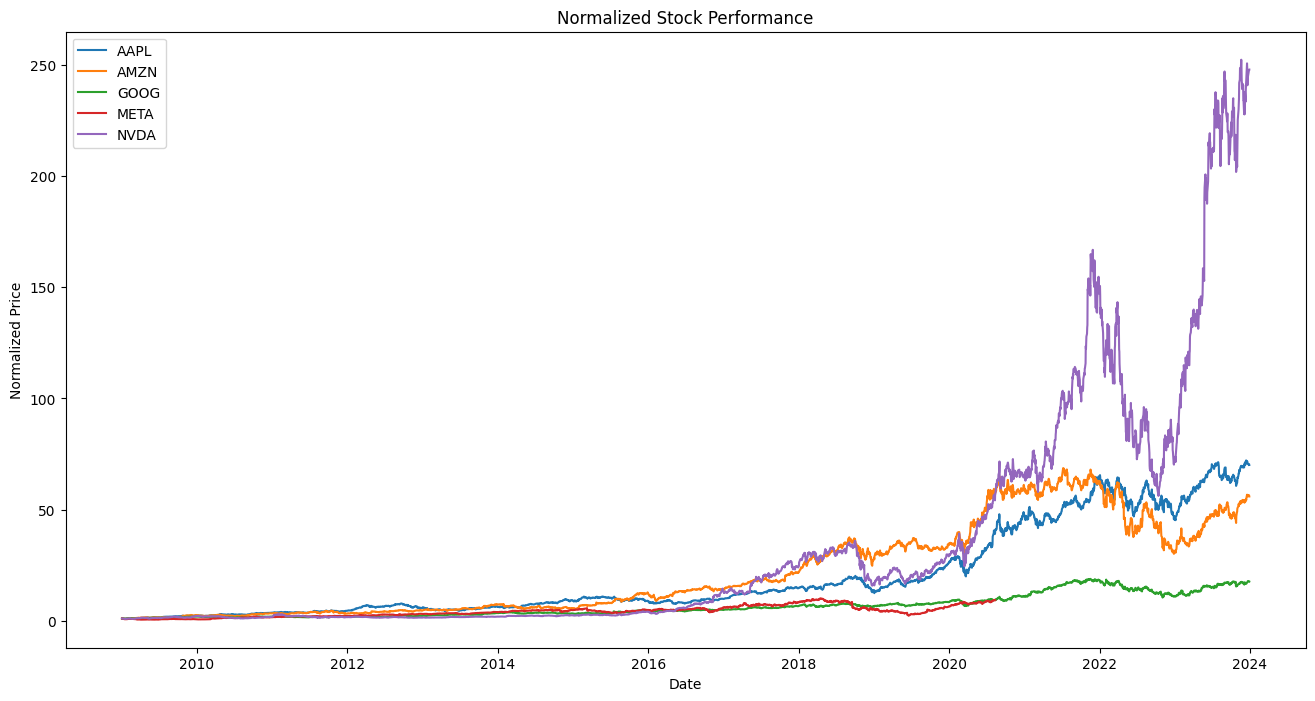

In [43]:
plt.figure(figsize=(16,8))

for stock in stocks:
    plt.plot(
        normalized_prices["Date"],
        normalized_prices[stock],
        label=stock
    )

plt.title("Normalized Stock Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Price")

plt.legend()

plt.show()

In [44]:
returns_df = pd.DataFrame()

In [45]:
for stock in stocks:
    temp_df = stock_data[stock]

    returns_df[stock] = temp_df["Close"].pct_change()

In [46]:
returns_df["Date"] = stock_data["AAPL"]["Date"].values

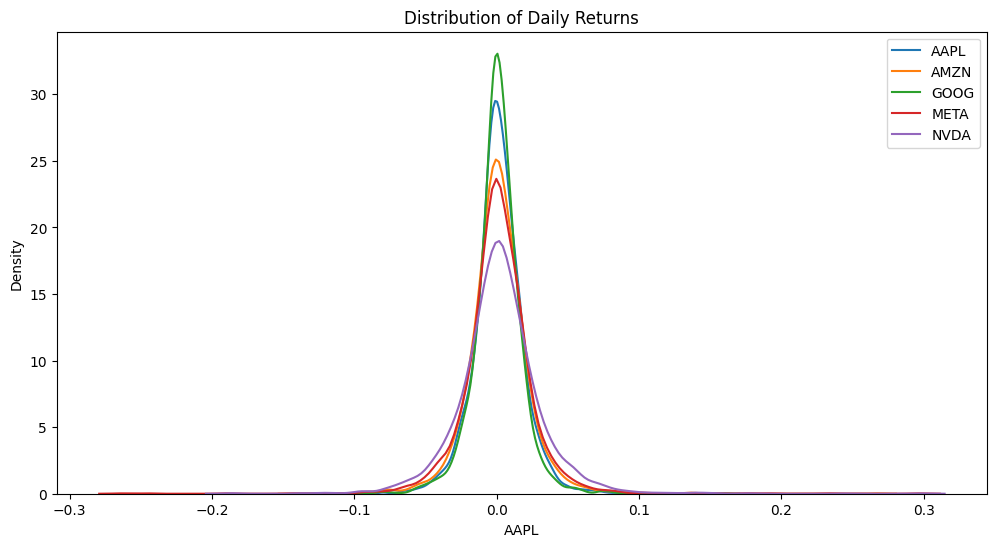

In [47]:
plt.figure(figsize=(12,6))

for stock in stocks:
    sns.kdeplot(returns_df[stock].dropna(), label=stock)

plt.title("Distribution of Daily Returns")

plt.legend()

plt.show()

In [48]:
correlation_matrix = returns_df[stocks].corr()

correlation_matrix

,AAPL,AMZN,GOOG,META,NVDA
AAPL,1.000000,0.472398,0.570600,0.000359,0.506192
AMZN,0.472398,1.000000,0.581239,0.007369,0.447627
GOOG,0.570600,0.581239,1.000000,0.009788,0.512466
META,0.000359,0.007369,0.009788,1.000000,0.022419
NVDA,0.506192,0.447627,0.512466,0.022419,1.000000


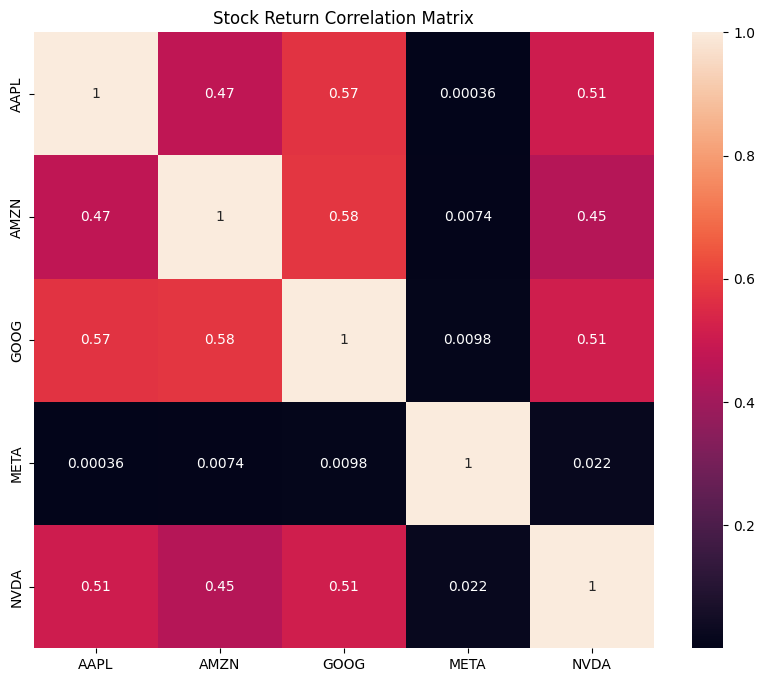

In [49]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title("Stock Return Correlation Matrix")

plt.show()

In [51]:
import os

os.listdir("../data/raw/data")

['.DS_Store', 'AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv']